# **Activity 1: The Machine Learning Data Pipeline - Group 3**

**Group members:**
- Abdullah Ali Saleem
- Danil Seksenov
- Nikita Soo
- Fatih Özdil

**Setup: Environment Preparation**

---

In [3]:
!pip install pandas seaborn matplotlib -q

##**Part 1: The Titanic Dataset (Real-World Data)**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
df_titanic = sns.load_dataset("titanic")

# Check Dataset Info (Data types and nulls)
print("--- Dataset Info ---")
df_titanic.info()

# Summary Statistics (Math snapshot)
print("\n--- Summary Statistics ---")
display(df_titanic.describe())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Summary Statistics ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Step 2: Data Cleaning (Imputation & Dropping)**

---

In [ ]:
# 1. Check missing values before cleaning
print("Missing values BEFORE cleaning:\n", df_titanic.isnull().sum())

# 2. Drop the 'deck' column (Too much missing data to save)
df_titanic = df_titanic.drop(columns=['deck'])

# 3. Impute (fill) missing ages with the median
median_age = df_titanic['age'].median()
df_titanic['age'] = df_titanic['age'].fillna(median_age)

# 4. Verify cleaning
print("\nMissing values AFTER cleaning:\n", df_titanic.isnull().sum()[['age']])

Missing values BEFORE cleaning:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values AFTER cleaning:
 age    0
dtype: int64


**Step 3: Exploratory Data Analysis (EDA)**

---

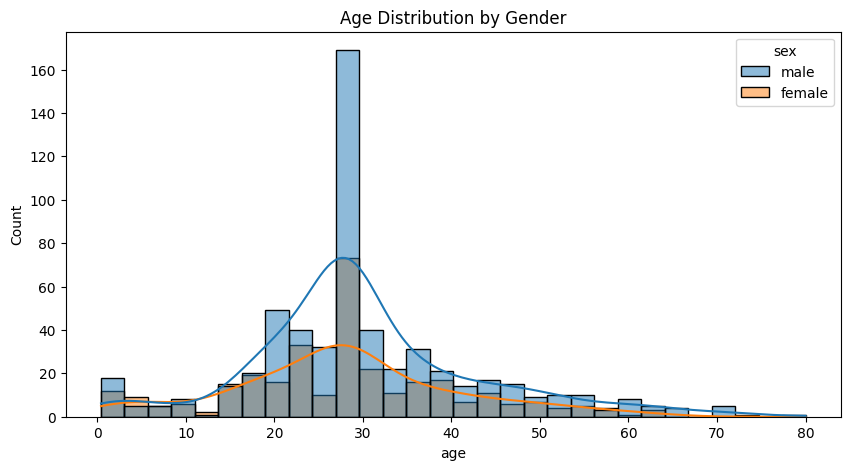

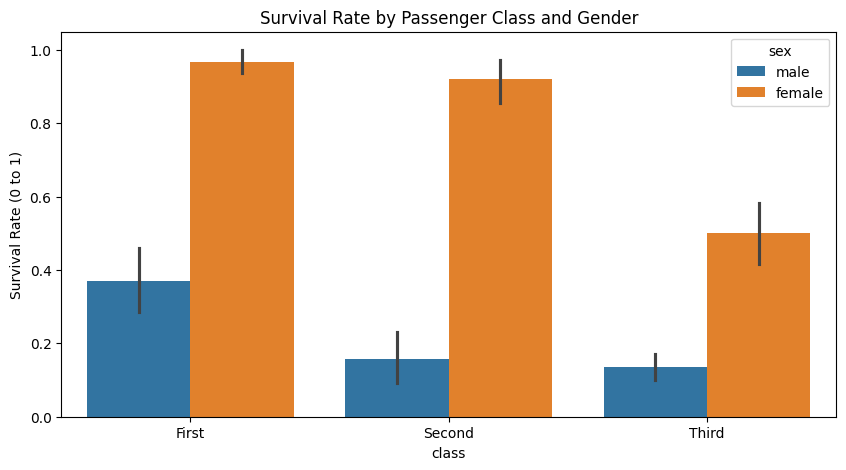

In [ ]:
# Plot 1: Age Distribution by Gender
plt.figure(figsize=(10, 5))
sns.histplot(data=df_titanic, x='age', kde=True, hue='sex')
plt.title('Age Distribution by Gender')
plt.show()

# Plot 2: Survival Rate by Passenger Class and Gender
plt.figure(figsize=(10, 5))
sns.barplot(data=df_titanic, x='class', y='survived', hue='sex')
plt.title('Survival Rate by Passenger Class and Gender')
plt.ylabel('Survival Rate (0 to 1)')
plt.show()

**Step 4: Feature Engineering**

---

In [ ]:
# 1. Create a new Feature (Family Size)
df_titanic['family_size'] = df_titanic['sibsp'] + df_titanic['parch']

# 2. One-Hot Encoding (Converting Text to Numbers)
# drop_first=True prevents the Dummy Variable Trap (if you aren't male, you must be female)
df_titanic = pd.get_dummies(df_titanic, columns=['sex'], drop_first=True)

display(df_titanic[['age', 'family_size', 'sex_male']].head())

,age,family_size,sex_male
0,22.0,1,True
1,38.0,1,False
2,26.0,0,False
3,35.0,1,False
4,35.0,0,True


In [ ]:
# 1. Create a new Feature (Family Size)
df_titanic['family_size'] = df_titanic['sibsp'] + df_titanic['parch']

# The 'sex' column has already been one-hot encoded in a previous step.
# Removing the redundant one-hot encoding line.

display(df_titanic[['age', 'family_size', 'sex_male']].head())

,age,family_size,sex_male
0,22.0,1,True
1,38.0,1,False
2,26.0,0,False
3,35.0,1,False
4,35.0,0,True


**Step 5: Preparing for Modeling**

---

In [ ]:
# Drop redundant columns created by Seaborn or text columns we can't use
columns_to_drop =[ 'alive', 'embark_town']
df_final = df_titanic.drop(columns=columns_to_drop)

print("Final Dataset ready for an ML Algorithm:")
df_final.info()

Final Dataset ready for an ML Algorithm:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  alone        891 non-null    bool    
 11  family_size  891 non-null    int64   
 12  sex_male     891 non-null    bool    
dtypes: bool(3), category(1), float64(2), int64(5), object(2)
memory usage: 66.4+ KB


##**Part 2: The Iris Dataset (Academic Data)**

**Step 1 & 2: Load, Understand, and (Attempt to) Clean**

---

In [5]:
import seaborn as sns
# 1. Load the Iris dataset
df_iris = sns.load_dataset("iris")

# 2. Check for missing values (Step 2: Cleaning)
print("--- Missing Values ---")
print(df_iris.isnull().sum())

--- Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


**Step 3: EDA (Finding the Best Predictors)**

---

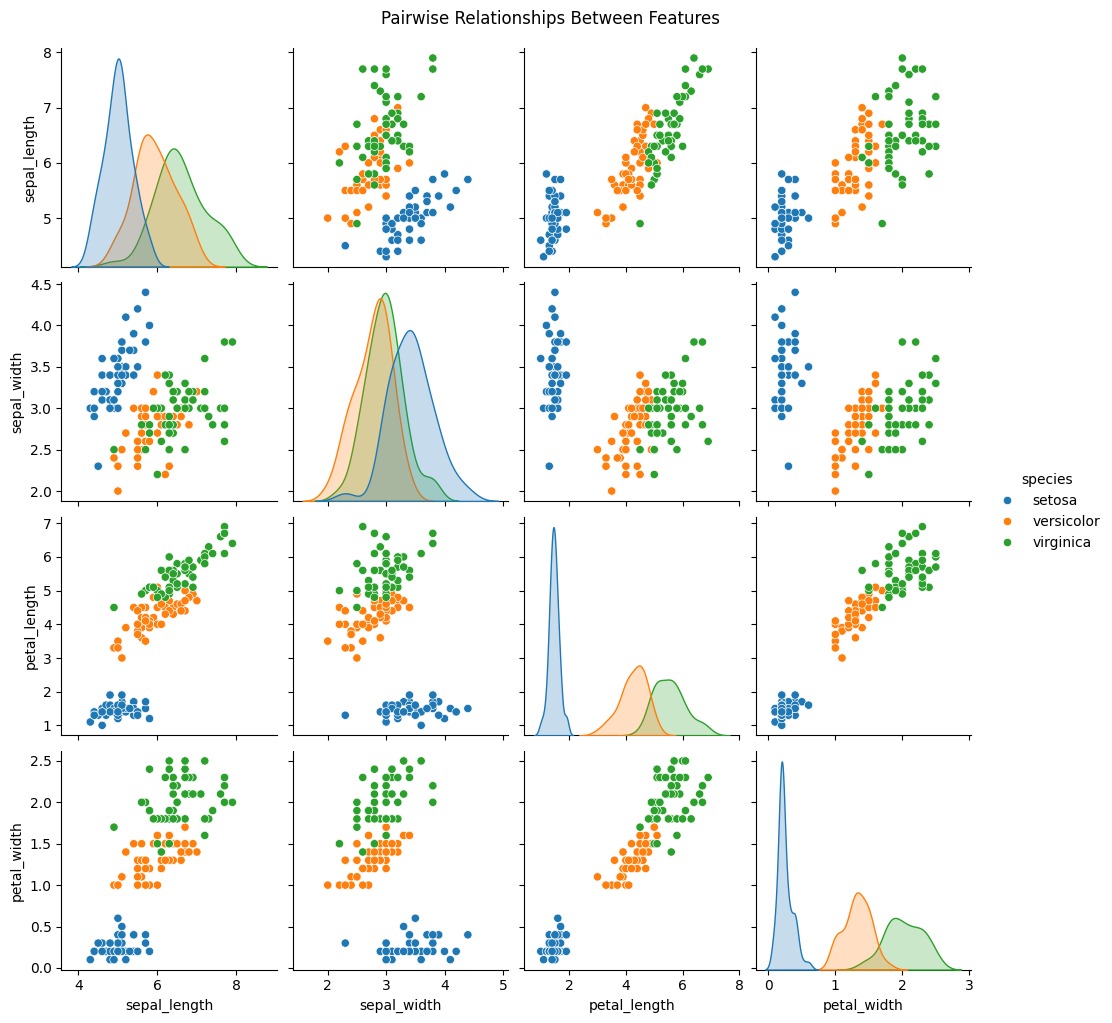

In [7]:
import matplotlib.pyplot as plt
# Create a pairplot (Visual Correlation check)
sns.pairplot(data=df_iris, hue='species')
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()